#  Calories Burn Prediction

Predicting calories burned during exercise using multiple ML regression models.

Models: Linear Regression · Polynomial Regression · Random Forest · XGBoost · Decision Tree · SVR (RBF) · SVR (Linear)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## 2. Load & Merge Data

In [2]:
dataset1 = pd.read_csv('calories.csv')
dataset2 = pd.read_csv('exercise.csv')

dataset = pd.merge(dataset2, dataset1, on='User_ID')
print('Dataset shape:', dataset.shape)
dataset.head()

Dataset shape: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('Null values:')
print(dataset.isnull().sum())
print('\nDuplicates:', dataset.duplicated().sum())
print('\nNumerical columns:', list(dataset.select_dtypes(include='number')))
print('Categorical columns:', list(dataset.select_dtypes(include='object')))

Null values:
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Duplicates: 0

Numerical columns: ['User_ID', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
Categorical columns: ['Gender']


In [4]:
dataset.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


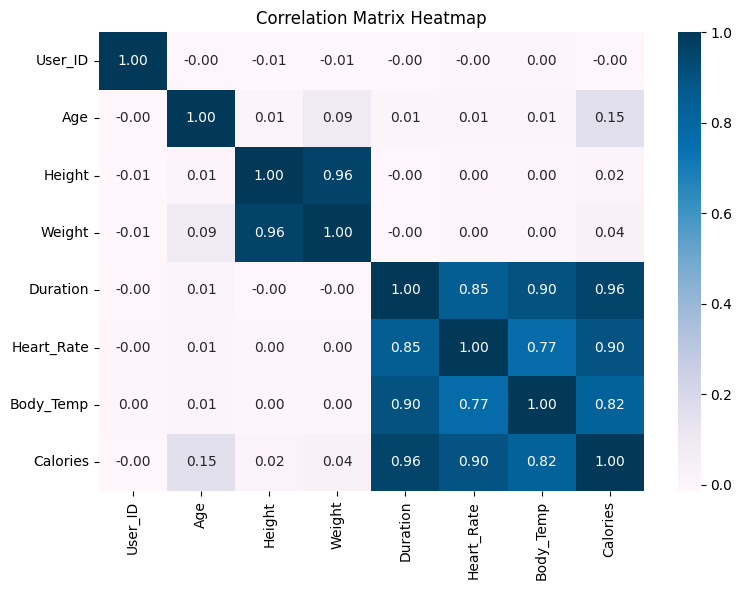

In [5]:
# Correlation Heatmap
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='PuBu', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

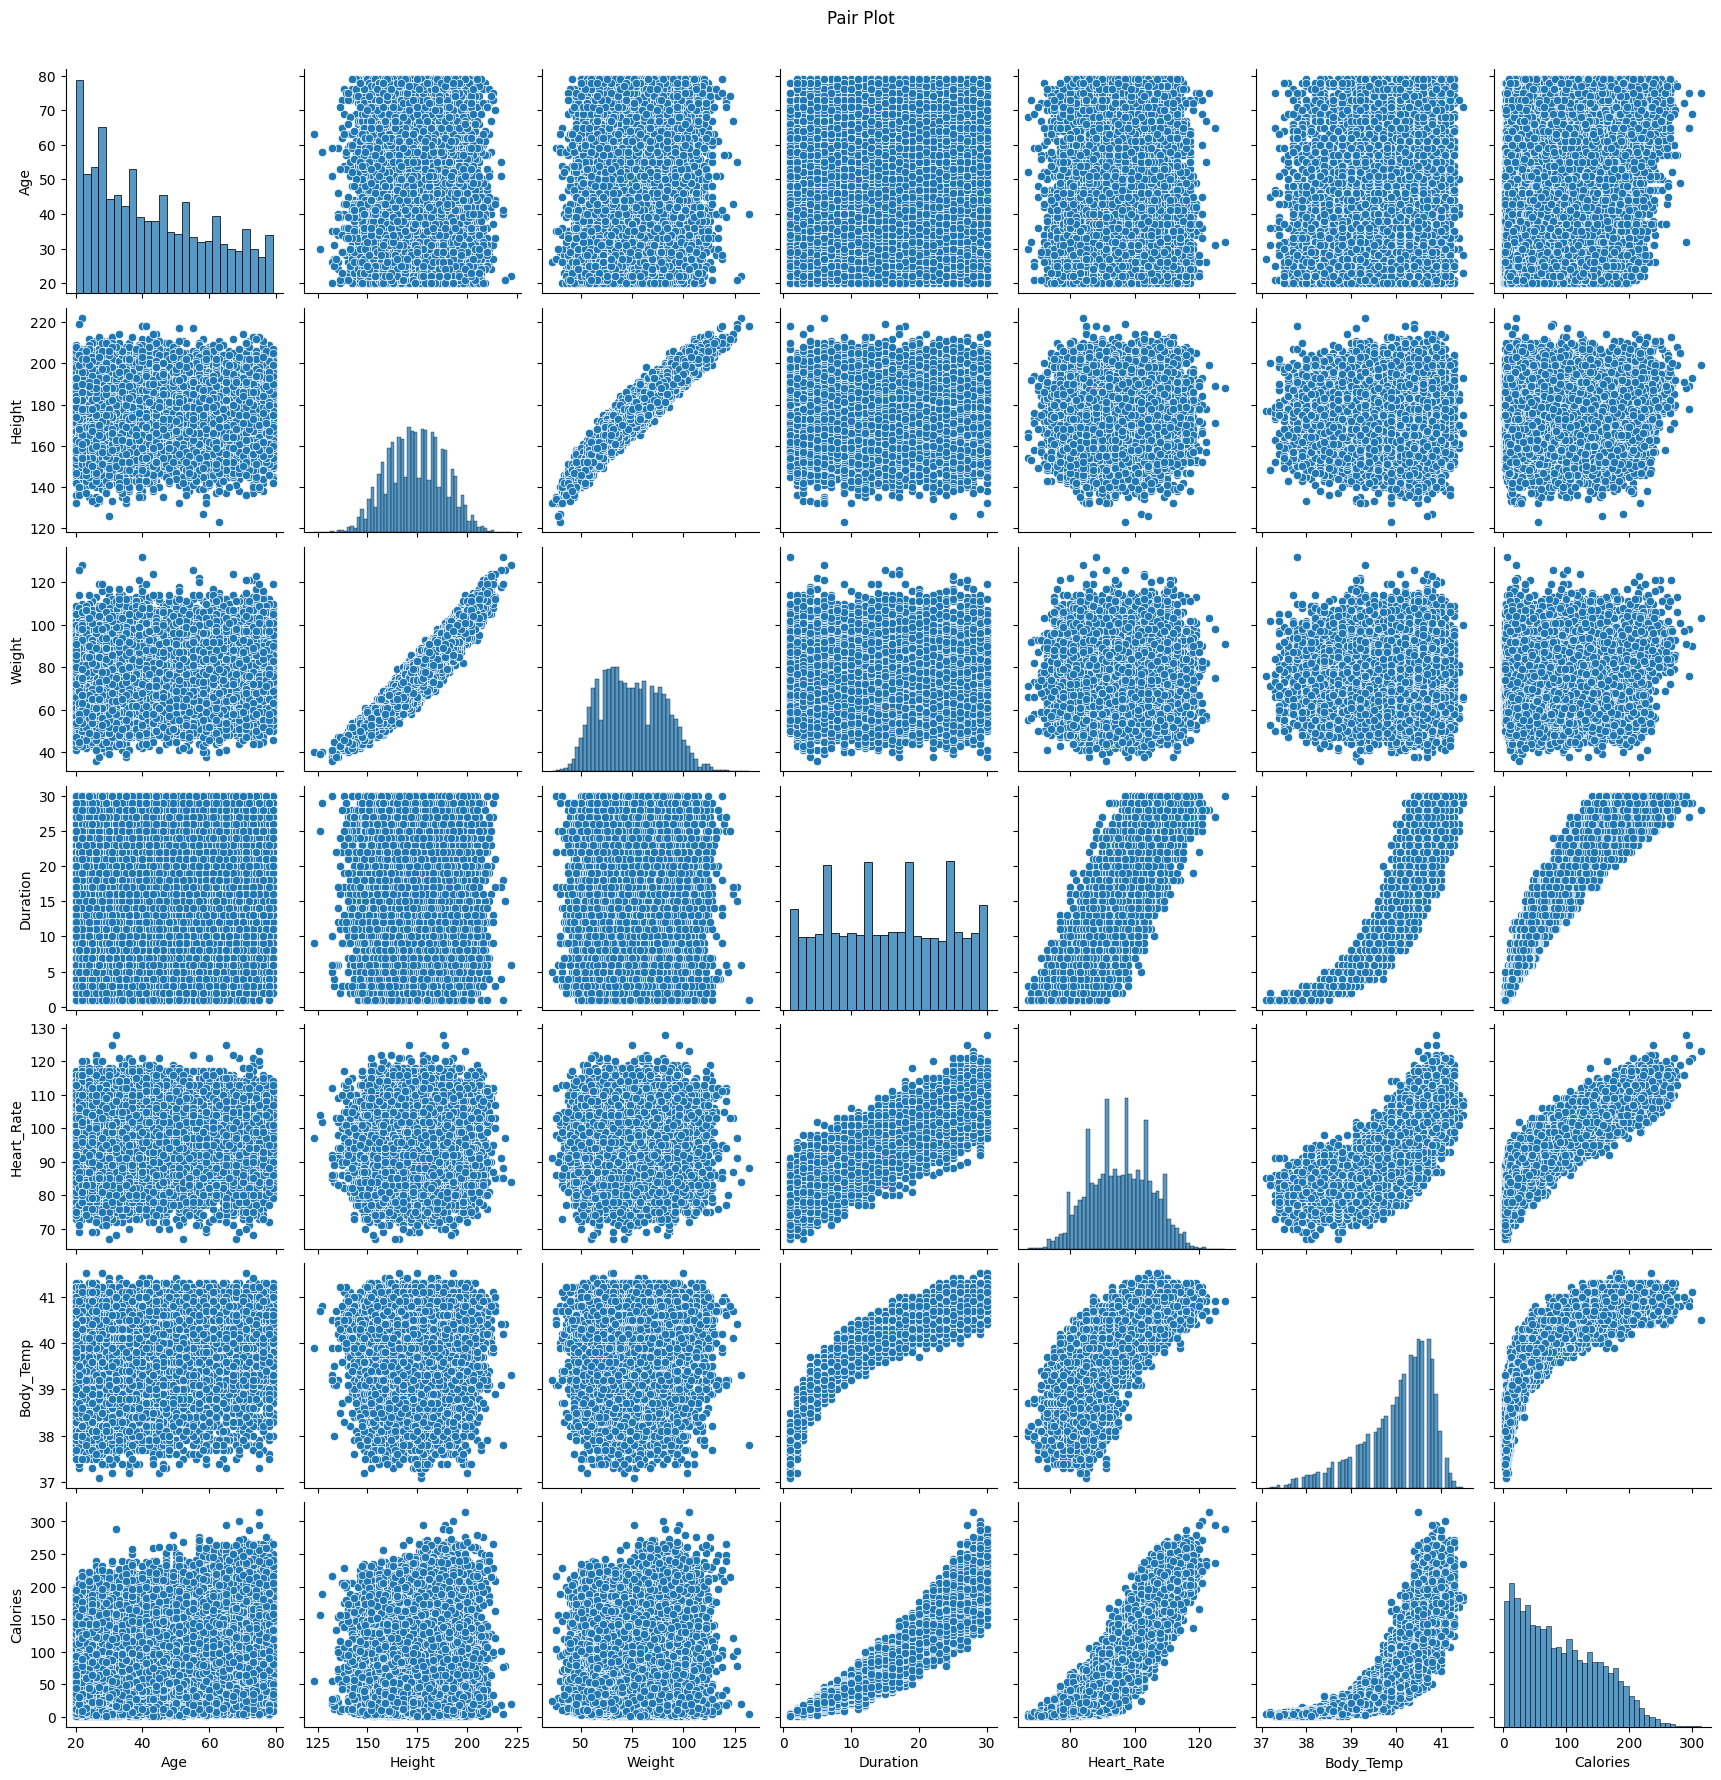

In [6]:
# Pair Plot
sns.pairplot(dataset.drop('User_ID', axis=1))
plt.suptitle('Pair Plot', y=1.02)
plt.show()

Average calories burned for males:   90.95
Average calories burned for females: 88.15


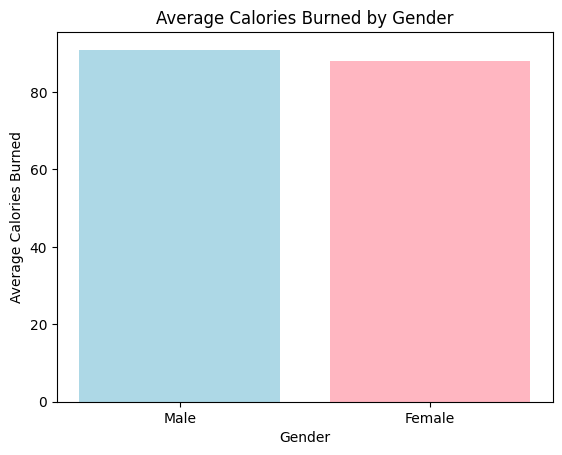

In [7]:
# Average calories burned by gender
female_avg_calories = dataset[dataset['Gender'] == 'female']['Calories'].mean()
male_avg_calories   = dataset[dataset['Gender'] == 'male']['Calories'].mean()

print('Average calories burned for males:  ', round(male_avg_calories, 2))
print('Average calories burned for females:', round(female_avg_calories, 2))

plt.bar(['Male', 'Female'], [male_avg_calories, female_avg_calories], color=['lightblue', 'lightpink'])
plt.xlabel('Gender')
plt.ylabel('Average Calories Burned')
plt.title('Average Calories Burned by Gender')
plt.show()

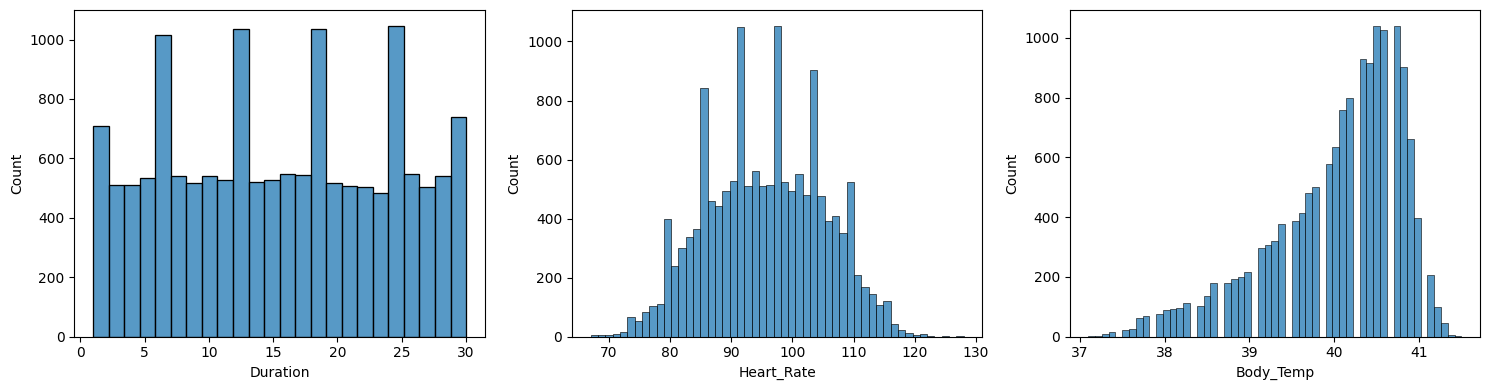

In [8]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(dataset, x='Duration',   ax=axes[0])
sns.histplot(dataset, x='Heart_Rate', ax=axes[1])
sns.histplot(dataset, x='Body_Temp',  ax=axes[2])
plt.tight_layout()
plt.show()

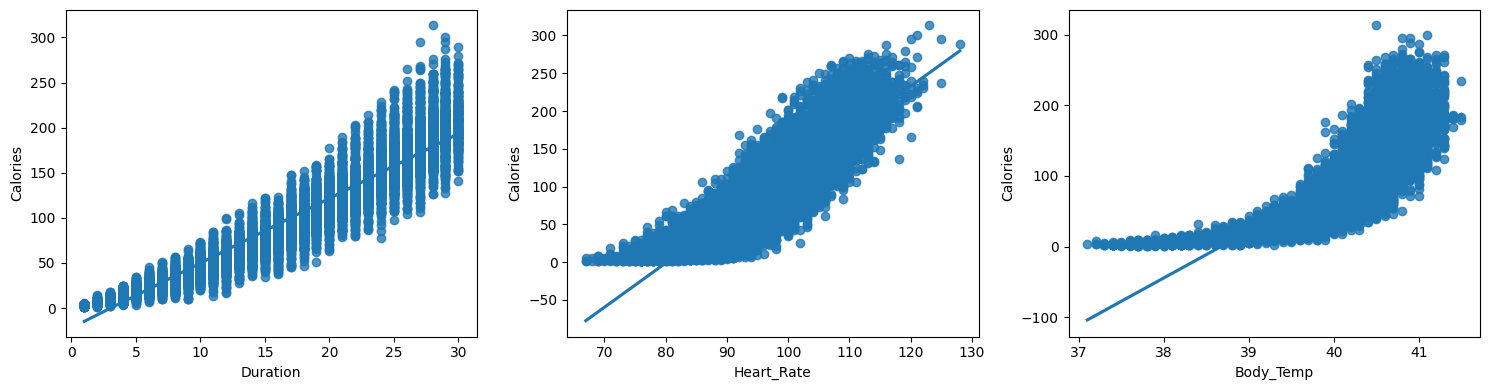

In [9]:
# Regression plots vs Calories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.regplot(x='Duration',   y='Calories', data=dataset, ax=axes[0])
sns.regplot(x='Heart_Rate', y='Calories', data=dataset, ax=axes[1])
sns.regplot(x='Body_Temp',  y='Calories', data=dataset, ax=axes[2])
plt.tight_layout()
plt.savefig('regression_plots.png')
plt.show()

## 4. Preprocessing

In [10]:
label_encoder = LabelEncoder()
dataset['Gender'] = label_encoder.fit_transform(dataset['Gender'])

dataset.drop('User_ID', axis=1, inplace=True)

X = dataset[['Duration', 'Body_Temp', 'Heart_Rate']].values
y = dataset['Calories'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=3)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (11250, 3)
Test size:  (3750, 3)


## 5. Model Training & Evaluation

### 1 — Linear Regression

In [11]:
# Build model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

MSE:  212.822
RMSE: 14.5884
R²:   0.9442


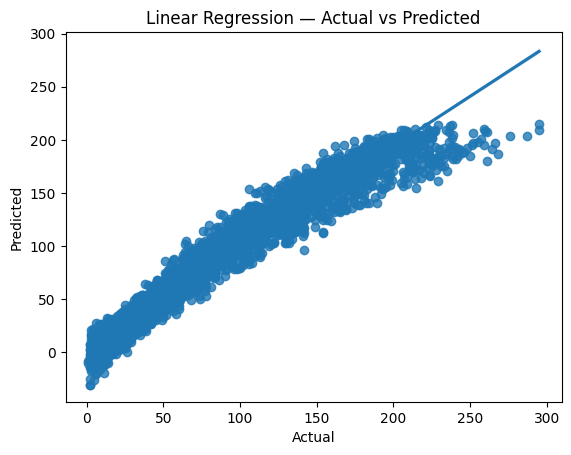

In [12]:
# Evaluation
y_pred_lr = model.predict(X_test)

print('MSE: ', round(mean_squared_error(y_test, y_pred_lr), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_lr), 4))

sns.regplot(x=y_test, y=y_pred_lr)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()

###2 — Polynomial Regression (degree=2)

In [13]:
# Build model
poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly  = poly_reg.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

LinearRegression()

MSE:  144.354
RMSE: 12.0147
R²:   0.9622


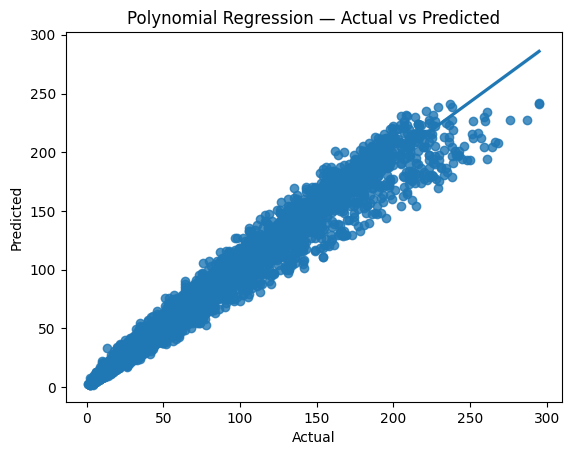

In [14]:
# Evaluation
y_pred_poly = lin_reg.predict(X_test_poly)

print('MSE: ', round(mean_squared_error(y_test, y_pred_poly), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_poly), 4))

sns.regplot(x=y_test, y=y_pred_poly)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Polynomial Regression — Actual vs Predicted')
plt.show()

In [15]:
# Cross Validation
kf = KFold(n_splits=10, shuffle=True, random_state=0)
cv_mse = cross_val_score(lin_reg, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_r2  = cross_val_score(lin_reg, X_train_poly, y_train, cv=kf, scoring='r2')

print('CV Mean MSE: ', round(-cv_mse.mean(), 4))
print('CV Mean RMSE:', round(np.sqrt(-cv_mse.mean()), 4))
print('CV Mean R²:  ', round(cv_r2.mean(), 4))

CV Mean MSE:  149.7168
CV Mean RMSE: 12.2359
CV Mean R²:   0.9619


### 3 — Random Forest

In [16]:
# Build model
rf = RandomForestRegressor(n_estimators=50, max_features=3, random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(max_features=3, n_estimators=50, random_state=0)

MSE:  185.7204
RMSE: 13.6279
R²:   0.9513


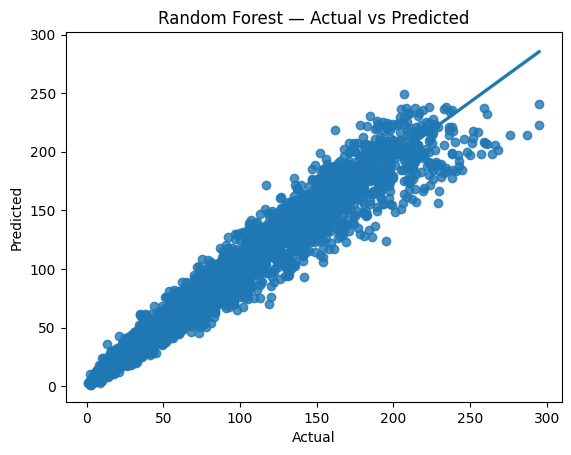

In [17]:
# Evaluation
y_pred_rf = rf.predict(X_test)

print('MSE: ', round(mean_squared_error(y_test, y_pred_rf), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_rf), 4))

sns.regplot(x=y_test, y=y_pred_rf)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Random Forest — Actual vs Predicted')
plt.show()

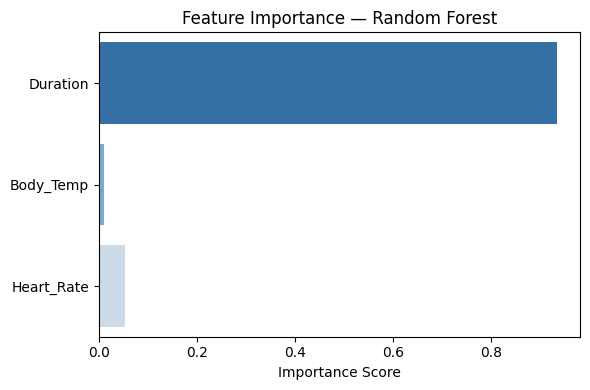

In [18]:
# Feature Importance — Random Forest
feature_names = ['Duration', 'Body_Temp', 'Heart_Rate']
importances_rf = rf.feature_importances_

plt.figure(figsize=(6, 4))
sns.barplot(x=importances_rf, y=feature_names, palette='Blues_r')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_rf.png')
plt.show()

### 4 — XGBoost

In [19]:
# Build model
xgb = XGBRegressor(random_state=0)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

MSE:  162.8815
RMSE: 12.7625
R²:   0.9573


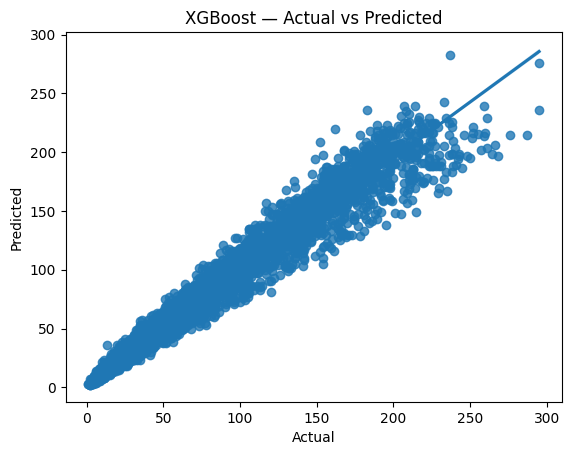

In [20]:
# Evaluation
y_pred_xgb = xgb.predict(X_test)

print('MSE: ', round(mean_squared_error(y_test, y_pred_xgb), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_xgb), 4))

sns.regplot(x=y_test, y=y_pred_xgb)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('XGBoost — Actual vs Predicted')
plt.show()

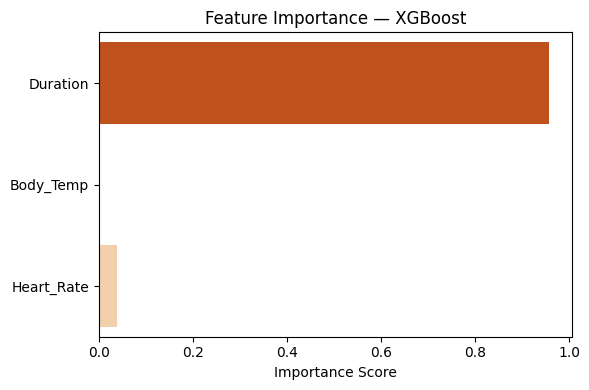

In [21]:
# Feature Importance — XGBoost
importances_xgb = xgb.feature_importances_

plt.figure(figsize=(6, 4))
sns.barplot(x=importances_xgb, y=feature_names, palette='Oranges_r')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png')
plt.show()

### 5 — Decision Tree

In [22]:
# Build model
dt_regressor = DecisionTreeRegressor(random_state=0)
dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

MSE:  217.5384
RMSE: 14.7492
R²:   0.943


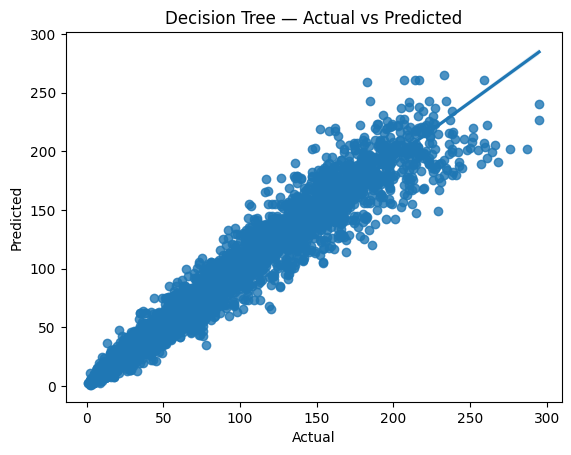

In [23]:
# Evaluation
y_pred_dt = dt_regressor.predict(X_test)

print('MSE: ', round(mean_squared_error(y_test, y_pred_dt), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_dt), 4))

sns.regplot(x=y_test, y=y_pred_dt)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Decision Tree — Actual vs Predicted')
plt.show()

### 6 — SVR (RBF Kernel)

In [24]:
# Build model
svr_rbf = SVR(kernel='rbf', C=10, gamma=0.01, epsilon=0.1)
svr_rbf.fit(X_train, y_train)

SVR(C=10, gamma=0.01)

MSE:  155.0822
RMSE: 12.4532
R²:   0.9594

CV Mean MSE: 159.4231


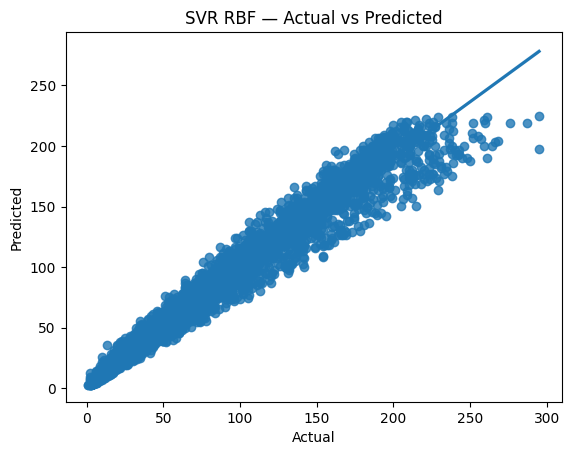

In [25]:
# Evaluation
y_pred_svr_rbf = svr_rbf.predict(X_test)

print('MSE: ', round(mean_squared_error(y_test, y_pred_svr_rbf), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_svr_rbf)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_svr_rbf), 4))

# Cross Validation
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_svr = cross_val_score(svr_rbf, X_train, y_train, cv=kf5, scoring='neg_mean_squared_error')
print('\nCV Mean MSE:', round(-cv_svr.mean(), 4))

sns.regplot(x=y_test, y=y_pred_svr_rbf)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('SVR RBF — Actual vs Predicted')
plt.show()

### 7 — SVR (Linear Kernel)

In [26]:
# Build model
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)

SVR(kernel='linear')

MSE:  225.968
RMSE: 15.0322
R²:   0.9408


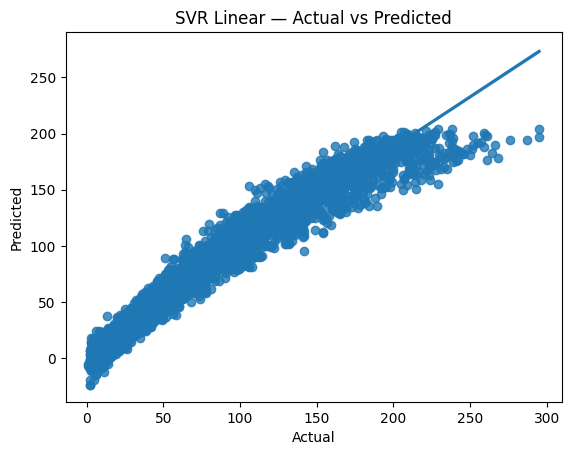

In [27]:
# Evaluation
y_pred_svr_linear = svr_linear.predict(X_test)

print('MSE: ', round(mean_squared_error(y_test, y_pred_svr_linear), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_svr_linear)), 4))
print('R²:  ', round(r2_score(y_test, y_pred_svr_linear), 4))

sns.regplot(x=y_test, y=y_pred_svr_linear)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('SVR Linear — Actual vs Predicted')
plt.show()

## 6. Models Comparison

In [28]:
results = {
    'Model': ['Linear Regression', 'Polynomial Regression', 'Random Forest',
               'XGBoost', 'Decision Tree', 'SVR (RBF)', 'SVR (Linear)'],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_svr_rbf)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_svr_linear)), 4),
    ],
    'R²': [
        round(r2_score(y_test, y_pred_lr), 4),
        round(r2_score(y_test, y_pred_poly), 4),
        round(r2_score(y_test, y_pred_rf), 4),
        round(r2_score(y_test, y_pred_xgb), 4),
        round(r2_score(y_test, y_pred_dt), 4),
        round(r2_score(y_test, y_pred_svr_rbf), 4),
        round(r2_score(y_test, y_pred_svr_linear), 4),
    ]
}

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,R²
0,Polynomial Regression,12.0147,0.9622
1,SVR (RBF),12.4532,0.9594
2,XGBoost,12.7625,0.9573
3,Random Forest,13.6279,0.9513
4,Linear Regression,14.5884,0.9442
5,Decision Tree,14.7492,0.9430
6,SVR (Linear),15.0322,0.9408


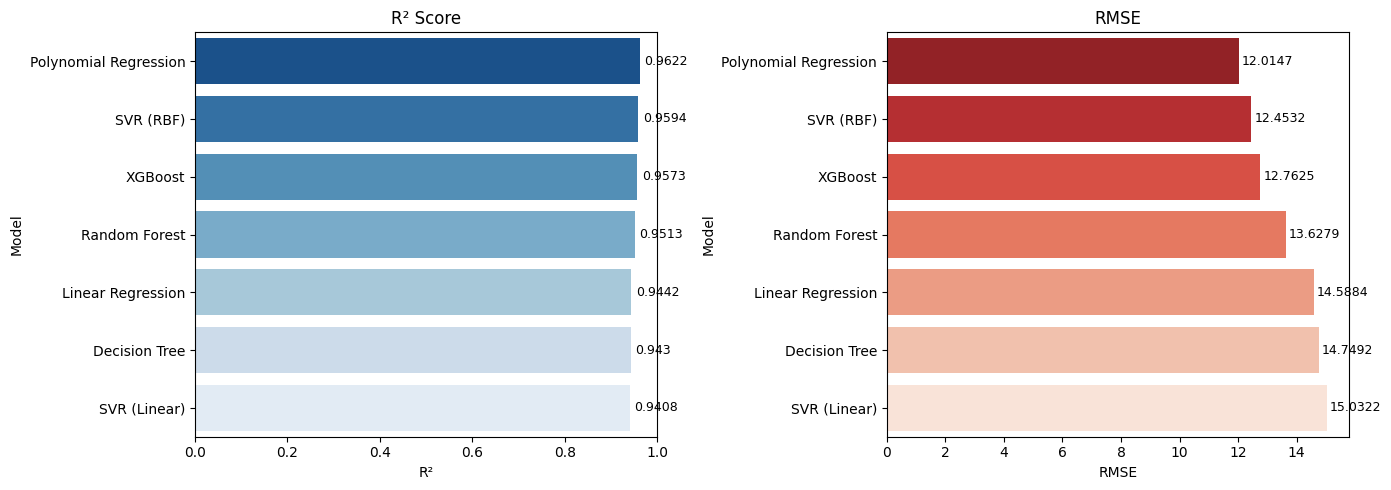

In [31]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² chart
bars1 = sns.barplot(data=results_df, x='R²', y='Model', palette='Blues_r', ax=axes[0])
axes[0].set_title('R² Score')
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.01, i, str(v), va='center', fontsize=9)

# RMSE chart
rmse_df = results_df.sort_values('RMSE')
bars2 = sns.barplot(data=rmse_df, x='RMSE', y='Model', palette='Reds_r', ax=axes[1])
axes[1].set_title('RMSE')
for i, v in enumerate(rmse_df['RMSE']):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('models_comparison.png')
plt.show()

## 7. Key Findings


- **Best performing model: Polynomial Regression** with R² = 0.9622 and RMSE = 12.01 — the highest accuracy among all models.
- **SVR (RBF)** comes in second (R² = 0.9594), followed by **XGBoost** (R² = 0.9573) — both handle non-linearity well.
- All models achieved R² above 0.94, indicating strong predictive power across the board.
- **Duration is the most important feature**, contributing ≈0.93 and ≈0.95 importance in Random Forest and XGBoost respectively, leaving minimal room for Heart_Rate and Body_Temp to contribute.
- This explains why Polynomial Regression performs best, when a single feature dominates, a simple non-linear transformation is enough .